# Visualize the Importance

In [1]:
import os, sys

sys.path.append(os.path.abspath("."))

In [2]:
os.chdir(CURRENT_ADDR := os.path.abspath(".."))

In [3]:
CURRENT_ADDR

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article'

## Importance

In [4]:
import math
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import os, sys
import pandas as pd

from glob import glob
from matplotlib import cm

In [5]:
import LoadDataFromDisk

## Functions

In [66]:
def visualize_importance_of_education(
    importance_df_addr_list: list, 
    save_address: str = "importance.jpg"
    ) -> None:
    importance_df_list = []
    for importance_df_addr in importance_df_addr_list:
        importance_df = pd.read_excel(importance_df_addr, index_col=0)
        importance_df_list.append(importance_df)

    # Define which indices you want to plot (your selection)
    plot_indices = [0, 1, 2, 3, 4, 5]

    # Define which variables to include for each subplot
    var_lists = [
        ['Literate Education Dummy', 'Illiterate Dummy', 'Education Year'],
        ['Literate Education Dummy', 'Illiterate Dummy', 'Education Year', 'Heard about Climate Change Probability'],
        ['Literate Education Dummy', 'Illiterate Dummy', 'Education Year', 
        'Heard about Climate Change Probability', 'Climate Change Awareness Probability'],
        ['Literate Education Dummy', 'Illiterate Dummy', 'Education Year', 
        'Heard about Climate Change Probability', 'Climate Change Awareness Probability'],
        ['Literate Education Dummy', 'Illiterate Dummy', 'Education Year', 
        'Heard about Climate Change Probability', 'Climate Change Awareness Probability'],
        ['Literate Education Dummy', 'Illiterate Dummy', 'Education Year', 
        'Heard about Climate Change Probability', 'Climate Change Awareness Probability']
    ]

    sub_figure_code = list("abcdefghijklmnopqrstuvwxyz")

    # Create subplots
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.flatten()

    for ax, idx, vars_to_plot in zip(axes, plot_indices, var_lists):
        df = importance_df_list[idx].loc[vars_to_plot, ['Mean_Importance', 'Std_Importance']]

        # Bar plot
        bars = ax.bar(
            df.index, 
            df['Mean_Importance'], 
            yerr=df['Std_Importance'], 
            capsize=6, 
            color='skyblue', 
            edgecolor='grey'
        )

        # Format axes
        ax.set_ylabel("Mean Importance")
        ax.set_xticklabels(df.index, rotation=25, ha='center')
        ax.grid(linestyle='--', alpha=0.6)
        
        # Add data labels as percentages
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height*100:.2f}%",
                ha='center', va='bottom', fontsize=9, fontweight='bold'
            )

        # Subplot label (e.g. a, b, c…)
        ax.text(
            0.02, 0.95, f"({sub_figure_code[idx]})",
            transform=ax.transAxes, fontsize=15,
            fontweight='bold', va='top', color='black'
        )

    # Layout and global adjustments
    plt.tight_layout()
    plt.savefig(save_address, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Violin plots saved to: {save_address}")

## Run

In [6]:
if __name__ == '__main__':
    pass

In [12]:
os.makedirs(MLD01e_RESULTS_ADDR := './MLD01e_Results', exist_ok=True)

In [23]:
importance_df_addr_list = sorted(glob(os.path.join(MLD01e_RESULTS_ADDR, 'Table*_Importance_*.xlsx')))

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_66289/3190298715.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, ha='center')
/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_66289/3190298715.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, ha='center')
/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_66289/3190298715.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, ha='center')
/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_66289/3190298715.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

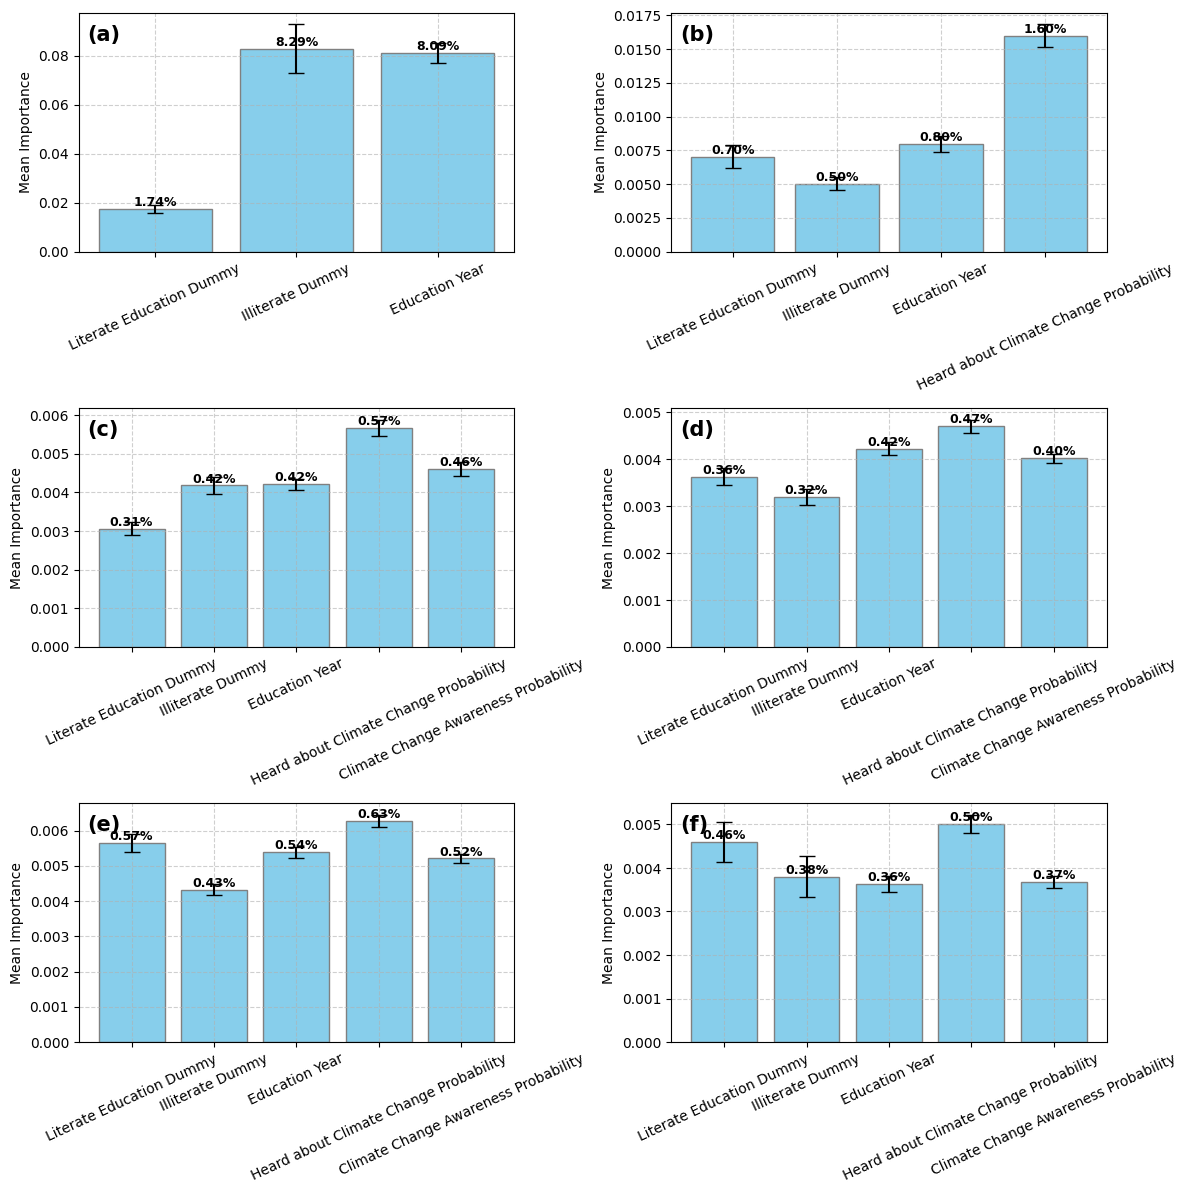

✅ Violin plots saved to: ./MLD01e_Figures/ImportanceOfEducation.jpg


In [67]:
visualize_importance_of_education(
    importance_df_addr_list=importance_df_addr_list,
    save_address='./MLD01e_Figures/ImportanceOfEducation.jpg'
    )